In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

In [2]:
def distancia(X, q, k):
    # distancia L_k de cada fila de X al punto q
    return (np.abs(X - q) ** k).sum(axis=1) ** (1 / k)

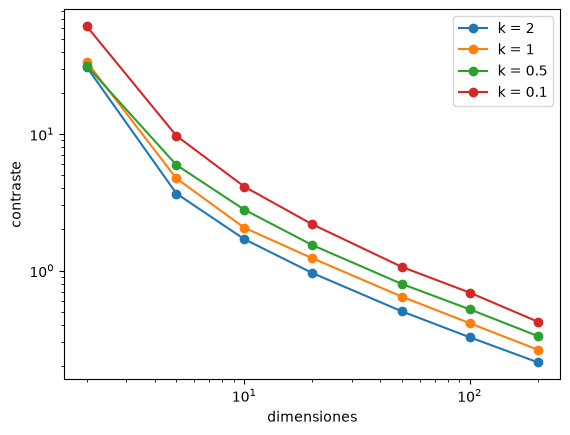

In [3]:
def contraste(d, k, n=100, repeticiones=50):
    valores = []
    for _ in range(repeticiones):
        X = np.random.rand(n, d)   # n puntos al azar
        q = np.random.rand(d)      # punto de consulta
        D = distancia(X, q, k)
        valores.append((D.max() - D.min()) / D.min())
    return np.mean(valores)

dims = [2, 5, 10, 20, 50, 100, 200]
for k in [2, 1, 0.5, 0.1]:
    plt.plot(dims, [contraste(d, k) for d in dims], "o-", label=f"k = {k}")

plt.xscale("log"); plt.yscale("log")
plt.xlabel("dimensiones"); plt.ylabel("contraste")
plt.legend(); plt.show()

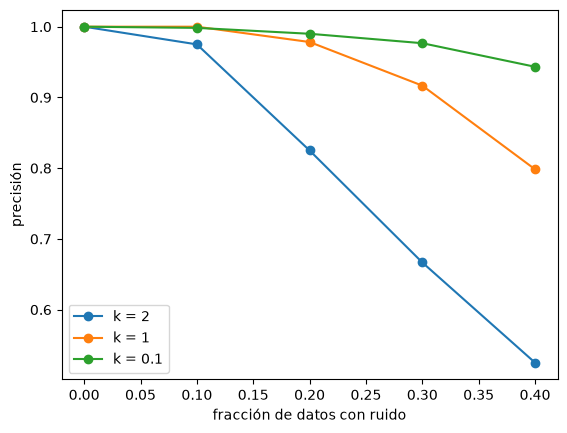

In [6]:
centros = np.random.rand(3, 50) * 4
X = np.vstack([c + np.random.randn(200, 50) for c in centros])
y = np.repeat([0, 1, 2], 200)

def precision(X, y, k):
    aciertos = 0
    for i in range(len(X)):
        D = distancia(X, X[i], k)
        D[i] = np.inf              # no contarse a sí mismo
        aciertos += y[D.argmin()] == y[i]
    return aciertos / len(X)

niveles = [0, 0.1, 0.2, 0.3, 0.4]
for k in [2, 1, 0.1]:
    res = []
    for r in niveles:
        Xr = X.copy()
        m = np.random.rand(*X.shape) < r               # valores a corromper
        Xr[m] = np.random.uniform(-8, 12, m.sum())     # ruido
        res.append(precision(Xr, y, k))
    plt.plot(niveles, res, "o-", label=f"k = {k}")

plt.xlabel("fracción de datos con ruido"); plt.ylabel("precisión")
plt.legend(); plt.show()